In [1]:
import jax
jax.config.update('jax_platform_name', 'cpu')

import jax.numpy as jnp
from jax import config, jit, random, grad, vmap, flatten_util, hessian
from jax_md.quantity import force
from jax import random

import scipy.integrate as integrate

from thermo_oscillator_network_fns import energy_network

from scipy.stats import multivariate_normal

import os

import matplotlib.pyplot as plt

<frozen importlib._bootstrap>:228: RuntimeWarning: scipy._lib.messagestream.MessageStream size changed, may indicate binary incompatibility. Expected 56 from C header, got 64 from PyObject


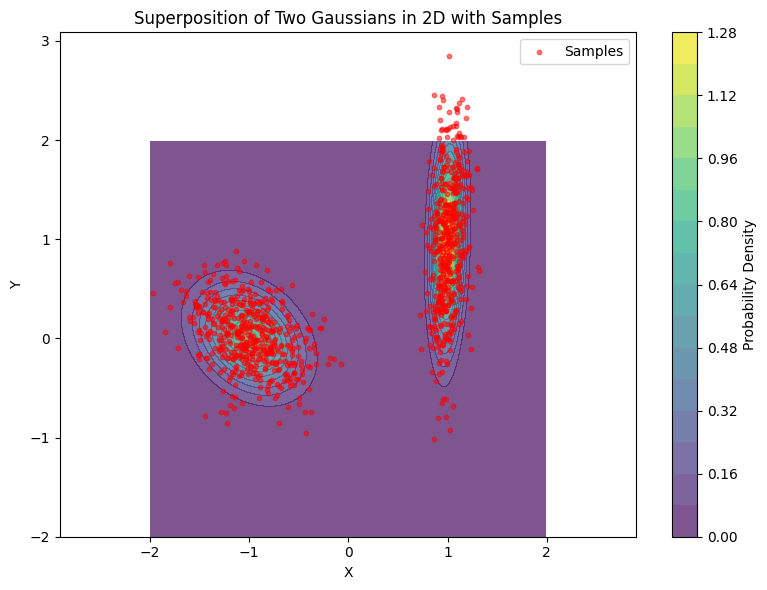

In [2]:
def sample_from_superposition(mu1, sigma1, mu2, sigma2, p1, n_samples, key):
    """
    Samples from a superposition of two Gaussian distributions in 2D using JAX.
    """
    key1, key2, key3 = random.split(key, 3)
    
    # Sample from both Gaussians
    samples1 = random.multivariate_normal(key1, mu1, sigma1, shape=(n_samples,))
    samples2 = random.multivariate_normal(key2, mu2, sigma2, shape=(n_samples,))
    
    # Generate random numbers to decide which sample to keep
    choices = random.uniform(key3, shape=(n_samples,)) < p1
    
    # Select samples based on the choices
    samples = jnp.where(choices[:, None], samples1, samples2)
    
    return samples

def gaussian_pdf(x, y, mu, sigma):
    """Compute the PDF of a 2D Gaussian distribution."""
    pos = jnp.dstack((x, y))
    return multivariate_normal.pdf(pos, mean=mu, cov=sigma)

# Parameters for the first Gaussian
mu1 = jnp.array([1, 1])
sigma1 = jnp.array([[0.01, 0.01], [0.01, 0.4]])

# Parameters for the second Gaussian
mu2 = jnp.array([-1, 0])
sigma2 = jnp.array([[0.1, -0.03], [-.03, 0.1]])

# Probability of sampling from the first Gaussian
p1 = 0.5

# Number of samples to generate
n_samples = 1000

# JAX random key
key = random.PRNGKey(0)

# Generate samples
samples = sample_from_superposition(mu1, sigma1, mu2, sigma2, p1, n_samples, key)

# Create a grid for the contour plot
x_lim = 2
y_lim = 2
x, y = jnp.mgrid[-x_lim:x_lim:.01, -y_lim:y_lim:.01]

# Compute the PDF for both Gaussians
z1 = gaussian_pdf(x, y, mu1, sigma1)
z2 = gaussian_pdf(x, y, mu2, sigma2)

# Combine the PDFs according to the mixture weights
z = p1 * z1 + (1 - p1) * z2

# Create the plot
plt.figure(figsize=(8, 6))

# Plot the contour of the combined distribution
plt.contourf(x, y, z, levels=20, cmap='viridis', alpha=0.7)
plt.colorbar(label='Probability Density')

# Plot the samples
plt.scatter(samples[:, 0], samples[:, 1], color='red', alpha=0.5, s=10, label='Samples')

plt.title('Superposition of Two Gaussians in 2D with Samples')
plt.xlabel('X')
plt.ylabel('Y')
plt.legend()
plt.axis('equal')
plt.tight_layout()
plt.show()

In [3]:
# Duffing params
k_lin= jnp.array([1., 1.,1.,1.])
k_duff = jnp.array([.5, .0, .0, .0])

connectivity = jnp.array([[0, 1], [1 , 2], [2, 3], [3, 0]])
c_lin = jnp.array([.0, .0, .0,0.])
c_optomech = jnp.array([0., .0, .0,0.])


marginalized_dofs = jnp.array([0,3])
non_marginalized_dofs = jnp.array([1,2])

In [4]:
def setup_integration(marginalized_dofs, integration_limits=(-2, 2), num_integration_points=10):
    integration_limits=(-2, 2)
    num_integration_points=10
    integration_grids = [jnp.linspace(integration_limits[0], integration_limits[1], num_integration_points) 
                                for _ in marginalized_dofs]
    marginalized_combinations = jnp.meshgrid(*integration_grids)
    marginalized_points = jnp.stack([grid.flatten() for grid in marginalized_combinations], axis=-1)

    def inegrator(fn):
        # Combine all possible combinations of marginalized DOFs
        integrated_vals = jnp.sum(vmap(fn)(marginalized_points)) * ((integration_limits[1] - integration_limits[0]) / num_integration_points) ** len(marginalized_dofs)
        return integrated_vals
    return inegrator


inegrator = setup_integration(marginalized_dofs)

In [5]:
def integrate_dofs(energy_fn, marginalized_dofs, non_marginalized_dofs):
    """
    Integrate out marginalized DOFs from the energy function.
    
    Args:
    energy_fn: The original energy function.
    marginalized_dofs: List of indices of DOFs to be integrated out.
    non_marginalized_dofs: List of indices of DOFs to keep.
    integration_limits: Tuple of (lower, upper) limits for integration.
    num_integration_points: Number of points for numerical integration.
    
    Returns:
    A new energy function that depends only on non-marginalized DOFs.
    """
            # Create integration grid for marginalized DOFs

    
    @jit
    def log_exp_energy_fn_marg(x_non_marginalized, *args):

        
        # Function to compute energy for each marginalized point
        def energy_for_marginalized_point(marginalized_point):
            # Combine non-marginalized and marginalized points
            full_x = jnp.zeros(len(marginalized_dofs) + len(non_marginalized_dofs))
            full_x = full_x.at[non_marginalized_dofs].set(x_non_marginalized)
            full_x = full_x.at[marginalized_dofs].set(marginalized_point)
            
            return jnp.exp(-energy_fn(full_x, *args))
        
        return jnp.log(inegrator(energy_for_marginalized_point))
    
    return log_exp_energy_fn_marg

if marginalized_dofs is not None:
    print("Marginalized DOFs")
    energy_network_marg = integrate_dofs(energy_network, marginalized_dofs, non_marginalized_dofs)
else:
    print("No marginalized DOFs")
    energy_network_marg = energy_network

Marginalized DOFs


In [6]:

def loss_fn(k_lin, k_duff, c_lin, c_optomech):
    # Redefine network_deformation_energy with current k1 and k2
    def current_network_energy(x):
        return energy_network_marg(x, k_lin, k_duff, c_lin, c_optomech, connectivity)
    
    # Recompute score and score2 with current energy function
    current_score = grad(current_network_energy)
    current_score2 = hessian(current_network_energy)
    
    # Recompute score_loss_per_sample with current score and score2
    current_score_loss_per_sample = lambda x: (-jnp.trace(current_score2(x)) + 1/2 * jnp.sum(current_score(x)**2))/n_samples   
    # Compute total loss
    return jnp.sum(vmap(current_score_loss_per_sample)(samples))

# Compute gradients of the loss with respect to k1 and k2
@jit
def grad_loss(k_lin, k_duff, c_lin, c_optomech):
    return grad(loss_fn, argnums=(0, 1, 2, 3))(k_lin, k_duff, c_lin, c_optomech)


In [17]:
# Optimization parameters
learning_rate = 0.001
num_iterations = 1001

# Initial values for k1 and k2
# k_lin_opt = k_lin
# k_duff_opt = k_duff
# c_lin_opt = c_lin
# c_optomech_opt = c_optomech
# # List to store loss values
# loss_values = []


design_mask = jnp.array([1, 1, 1, 1])

# Optimization loop
for i in range(num_iterations+1):
    # Compute gradients
    grads = grad_loss(k_lin_opt, k_duff_opt, c_lin_opt, c_optomech_opt)
    
    # Update k1 and k2
    k_lin_opt = k_lin_opt - learning_rate * grads[0]*design_mask[0]
    k_duff_opt = k_duff_opt - learning_rate * grads[1]*design_mask[1]
    c_lin_opt = c_lin_opt - learning_rate * grads[2]*design_mask[2]
    c_optomech_opt = c_optomech_opt - learning_rate * grads[3]*design_mask[3]
    
    # Save and print progress every 100 iterations
    if i % 10 == 0 or i == num_iterations:
        current_loss = loss_fn(k_lin_opt, k_duff_opt, c_lin_opt, c_optomech_opt)
        loss_values.append(jnp.float32(current_loss))
        print(f"Iteration {i}, Loss: {current_loss}, k_lin: {k_lin_opt}, k_duff: {k_duff_opt}, c_lin: {c_lin_opt}, c_optomech: {c_optomech_opt}")

Iteration 0, Loss: -8.708335876464844, k_lin: [0.80497605 1.5768847  1.1325113  0.91750914], k_duff: [ 0.21181211 -2.0200226   0.0387856  -0.18788375], c_lin: [-0.46781301  0.6238729  -0.9063246  -1.0028106 ], c_optomech: [ 0.6923107   0.18759863 -0.11908542  0.58521974]
Iteration 10, Loss: -8.767780303955078, k_lin: [0.8029538 1.5861355 1.1337417 0.9175047], k_duff: [ 0.20621863 -2.0208352   0.03941679 -0.18789738], c_lin: [-0.47241035  0.6387255  -0.9122144  -1.011192  ], c_optomech: [ 0.70011854  0.18441786 -0.12560298  0.58855355]
Iteration 20, Loss: -8.825508117675781, k_lin: [0.8009936  1.5954086  1.1349809  0.91750056], k_duff: [ 0.20077913 -2.0216422   0.04005384 -0.18791032], c_lin: [-0.4769145   0.65342325 -0.9180522  -1.0193437 ], c_optomech: [ 0.70773685  0.18129021 -0.1319884   0.5917522 ]
Iteration 30, Loss: -8.881549835205078, k_lin: [0.79909223 1.6046996  1.1362294  0.9174964 ], k_duff: [ 0.19548683 -2.0224495   0.04069664 -0.18792257], c_lin: [-0.48132658  0.66795725 -

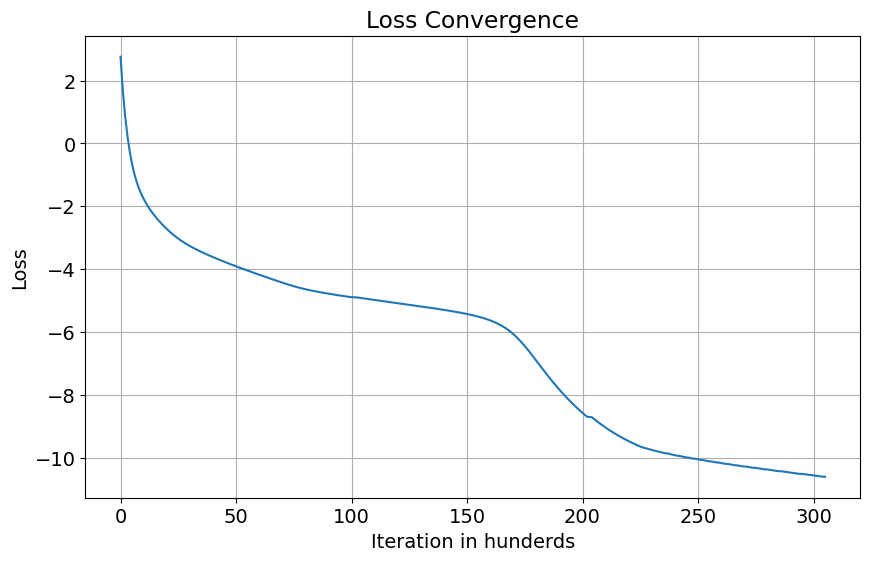

In [18]:
plt.figure(figsize=(10, 6))
plt.plot( loss_values)
plt.title('Loss Convergence')
plt.xlabel('Iteration in hunderds')
plt.ylabel('Loss')
# plt.yscale('log')  # Use log scale for y-axis to better visualize the convergence
plt.grid(True)
# Show the plot (optional, you can comment this out if you don't need to display it)
plt.show()

# # Create a descriptive filename
# folder_filename = f"2d_mu1_{mu1[0]:.1f}_{mu1[1]:.1f}_mu2_{mu2[0]:.1f}_{mu2[1]:.1f}"

# convergence_filename = f"free_dofs_{len(non_marginalized_dofs)}_marginalized_dofs_{len(marginalized_dofs)}_"
# convergence_filename += f"k_lin_opt_{'yes' if design_mask[0]==1 else 'no'}_"
# convergence_filename += f"k_duff_opt_{'yes' if design_mask[1]==1 else 'no'}_"
# convergence_filename += f"c_lin_opt_{'yes' if design_mask[2]==1 else 'no'}_"
# convergence_filename += f"c_optomech_opt_{'yes' if design_mask[3]==1 else 'no'}_"
# convergence_filename += f"numSamples_{n_samples}_numIterations_{num_iterations}_finalLoss_{loss_values[-1]:.2f}_convergence.png"


# # Create the folder if it doesn't exist
# folder_path = f'results/{folder_filename}'
# os.makedirs(folder_path, exist_ok=True)

# # Save the figure
# plt.savefig(f'{folder_path}/{convergence_filename}', dpi=300, bbox_inches='tight')





In [19]:
inegrator_plot = setup_integration(non_marginalized_dofs)

# Plot Network Deformation Energy for original and optimized k values, and distribution with samples
x1_values = jnp.linspace(-x_lim, x_lim, 20)
x2_values = jnp.linspace(-y_lim, y_lim, 20)
X1, X2 = jnp.meshgrid(x1_values, x2_values)

# Calculate energy values for original k
energy_values_original = vmap(lambda x1, x2: energy_network_marg(jnp.array([x1, x2]).T, k_lin, k_duff, c_lin, c_optomech, connectivity))(X1.ravel(), X2.ravel())
energy_values_original = energy_values_original.reshape(X1.shape)

# Calculate energy values for optimized k
energy_values_optimized = vmap(lambda x1, x2: energy_network_marg(jnp.array([x1, x2]).T, k_lin_opt, k_duff_opt, c_lin_opt, c_optomech_opt, connectivity))(X1.ravel(), X2.ravel())
energy_values_optimized = energy_values_optimized.reshape(X1.shape)



# Calculate probability values for the entire grid
prob_from_energy_opt = lambda x1, x2: jnp.exp(-energy_network_marg(jnp.array([x1, x2]).T, k_lin_opt, k_duff_opt, c_lin_opt, c_optomech_opt, connectivity))
prob_from_energy_vals = vmap(vmap(prob_from_energy_opt))(X1, X2)


# Normalize the probability values using the custom integrator
def integrand(x):
    return jnp.exp(-energy_network_marg(x, k_lin_opt, k_duff_opt, c_lin_opt, c_optomech_opt, connectivity))

# Use the custom integrator
norm_const_opt = inegrator_plot(integrand)

prob_from_energy_normalized = prob_from_energy_vals / norm_const_opt


In [20]:
energy_values_original

Array([[-2.5745246 , -2.175633  , -1.8210622 , -1.5108129 , -1.2448847 ,
        -1.0232781 , -0.845993  , -0.7130289 , -0.62438625, -0.58006483,
        -0.58006483, -0.62438625, -0.7130289 , -0.845993  , -1.0232781 ,
        -1.2448851 , -1.5108129 , -1.8210622 , -2.175633  , -2.5745246 ],
       [-2.175633  , -1.7767411 , -1.4221703 , -1.1119211 , -0.8459928 ,
        -0.62438637, -0.44710115, -0.31413704, -0.22549435, -0.18117312,
        -0.18117312, -0.22549435, -0.31413704, -0.44710115, -0.62438637,
        -0.8459933 , -1.1119211 , -1.4221703 , -1.7767411 , -2.175633  ],
       [-1.8210622 , -1.4221703 , -1.0675995 , -0.7573502 , -0.49142203,
        -0.2698155 , -0.09253019,  0.04043381,  0.12907644,  0.17339782,
         0.17339782,  0.12907644,  0.04043381, -0.09253019, -0.2698155 ,
        -0.49142233, -0.7573502 , -1.0675995 , -1.4221703 , -1.8210622 ],
       [-1.5108129 , -1.1119211 , -0.7573502 , -0.44710097, -0.18117276,
         0.0404337 ,  0.21771896,  0.35068294,  

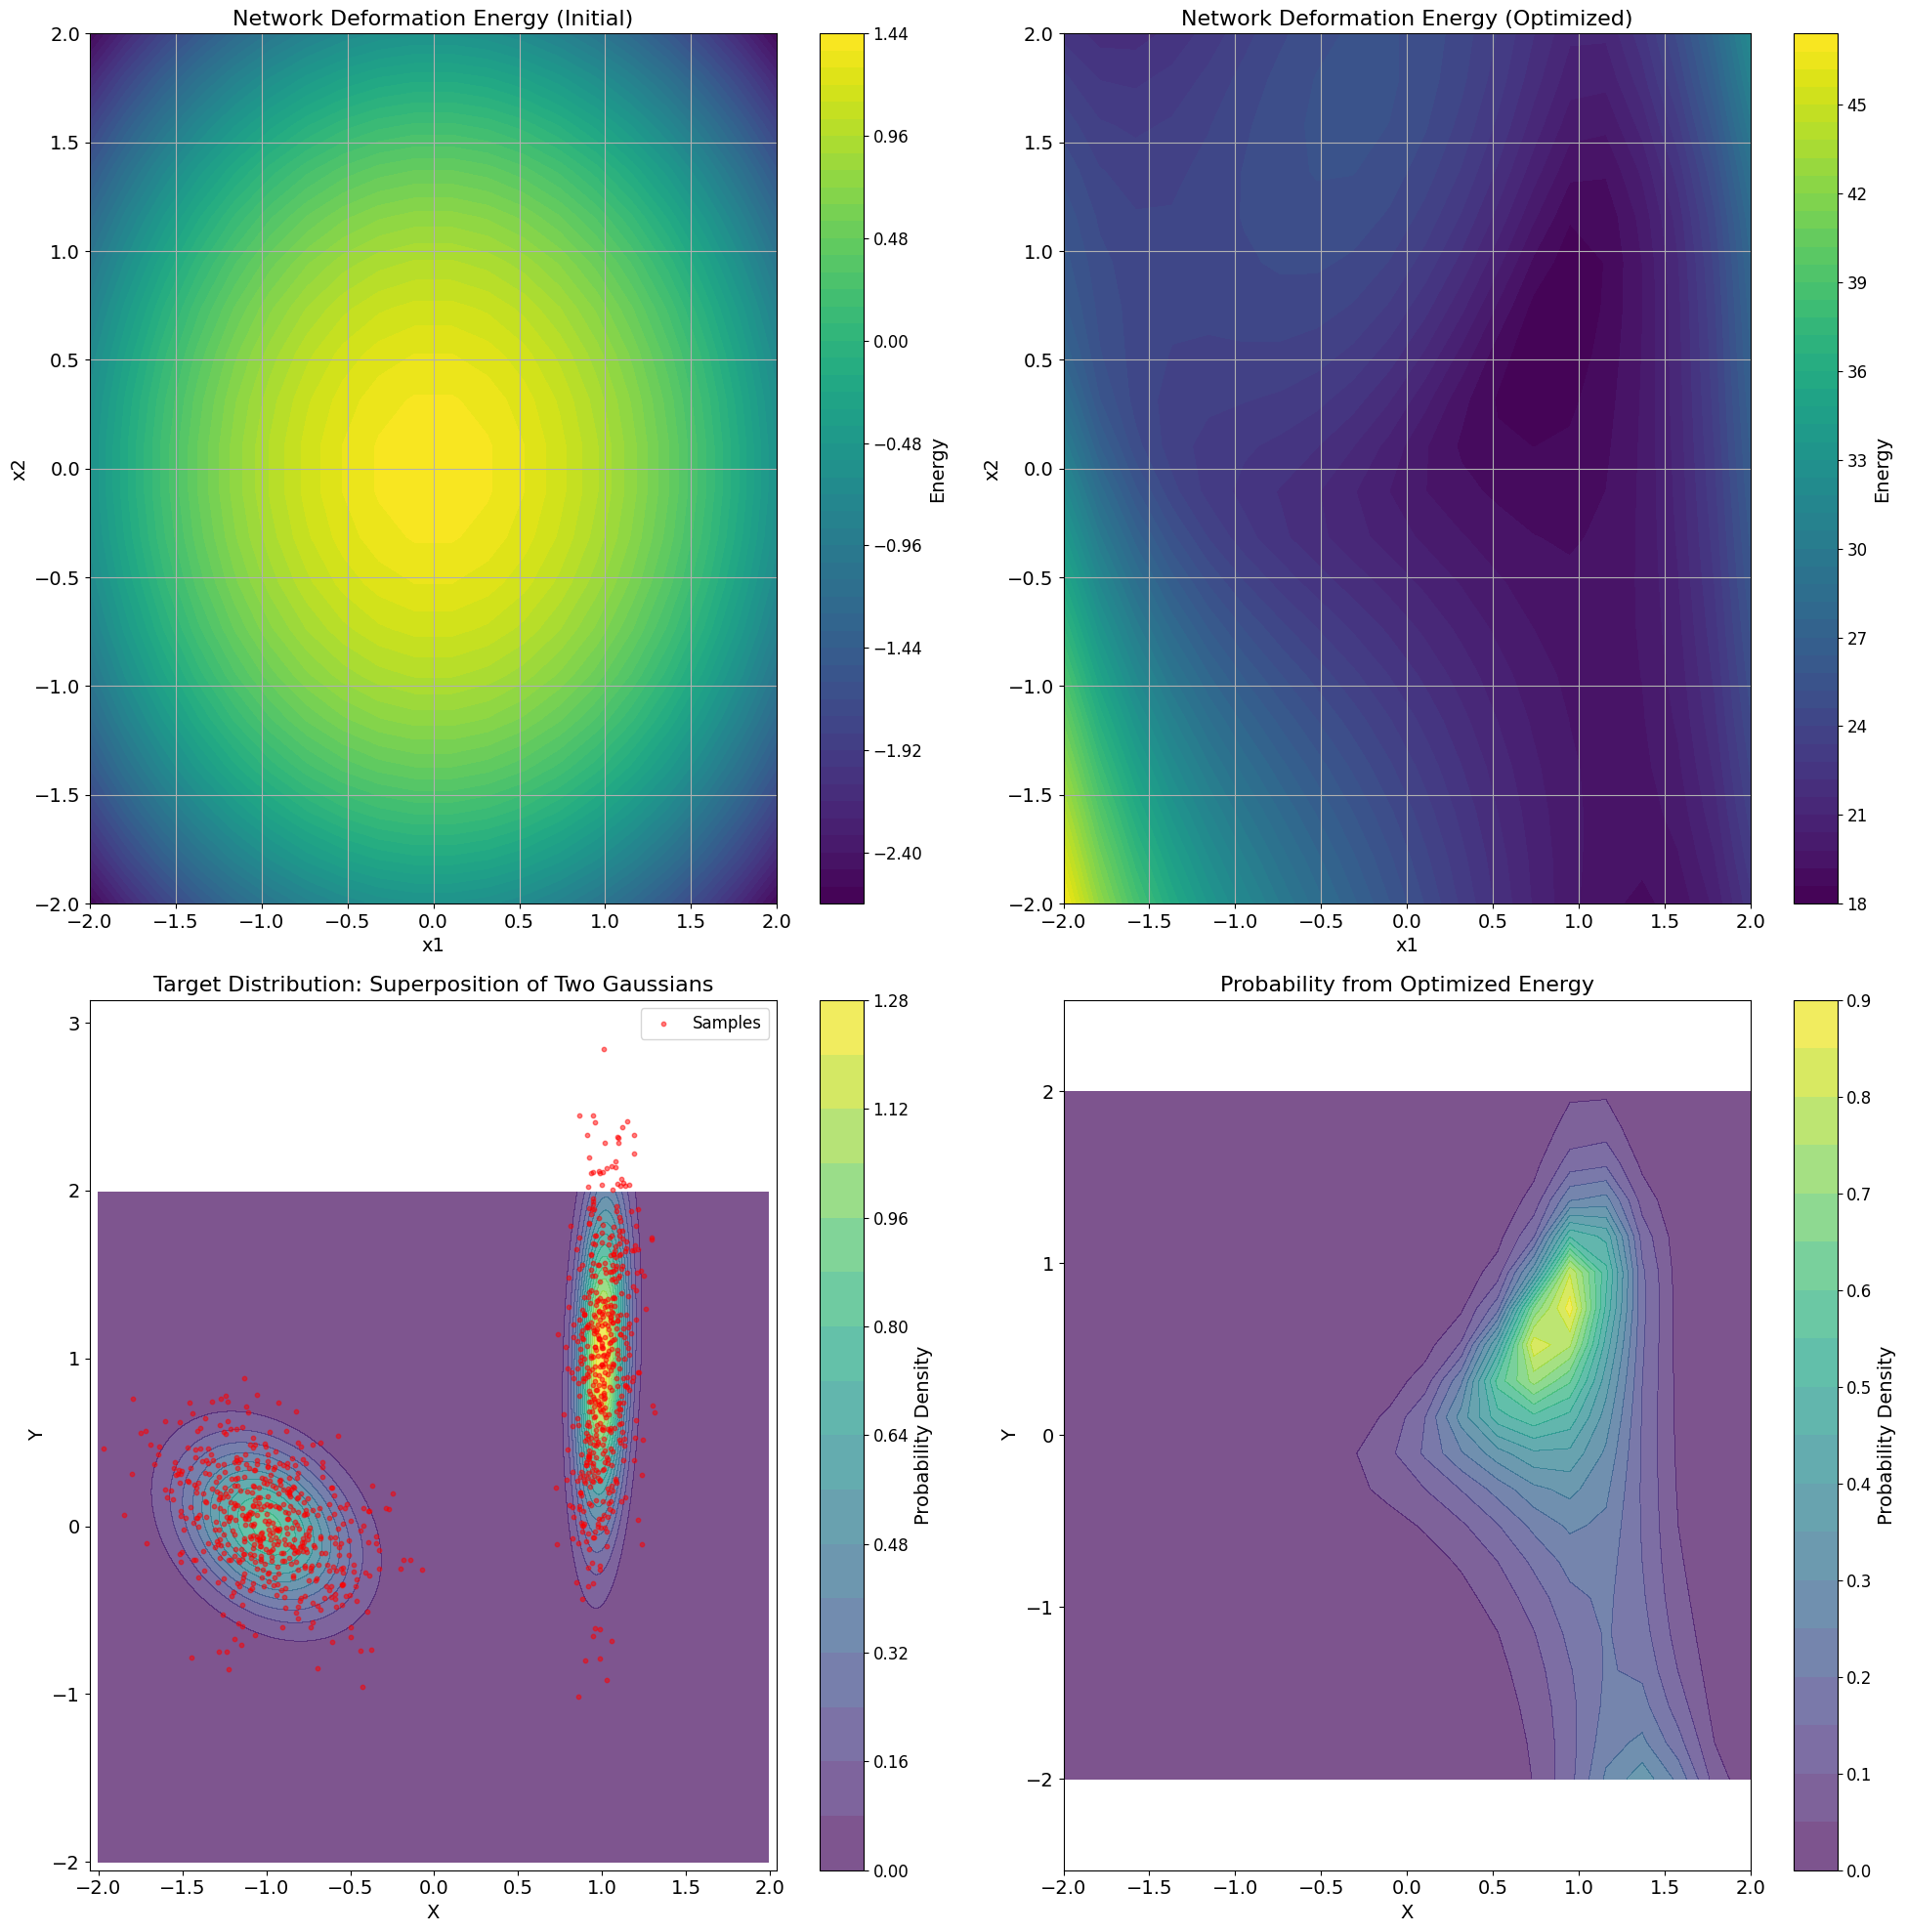

Original k_lin: [1. 1. 1. 1.], k_duff: [0.5 0.  0.  0. ], c_lin: [0. 0. 0. 0.], c_optomech: [0. 0. 0. 0.]
Optimized k_lin: [0.7590532 2.420188  1.3072299 1.0156217], k_duff: [-0.00369604 -2.281233    0.08205744  0.00722776], c_lin: [-0.6209712  1.1930063 -1.1237792 -1.112564 ], c_optomech: [ 0.92837924  0.03705044 -0.30383903  0.52541906]


In [21]:
# ... (previous code remains the same)

# Create 2x2 subplots
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(20, 20))

# Increase font size for all text elements
plt.rcParams.update({'font.size': 14})

# Plot original k energy
contour1 = ax1.contourf(X1, X2, energy_values_original, levels=50, cmap='viridis')
cbar1 = fig.colorbar(contour1, ax=ax1)
cbar1.set_label('Energy', fontsize=14)
ax1.set_title("Network Deformation Energy (Initial)", fontsize=16)
ax1.set_xlabel("x1", fontsize=14)
ax1.set_ylabel("x2", fontsize=14)
ax1.grid(True)

# Plot optimized k energy
contour2 = ax2.contourf(X1, X2, energy_values_optimized, levels=50, cmap='viridis')
cbar2 = fig.colorbar(contour2, ax=ax2)
cbar2.set_label('Energy', fontsize=14)
ax2.set_title("Network Deformation Energy (Optimized)", fontsize=16)
ax2.set_xlabel("x1", fontsize=14)
ax2.set_ylabel("x2", fontsize=14)
ax2.grid(True)

# Plot target distribution
x, y = jnp.mgrid[-x_lim:x_lim:.01, -y_lim:y_lim:.01]
z1 = gaussian_pdf(x, y, mu1, sigma1)
z2 = gaussian_pdf(x, y, mu2, sigma2)
z = p1 * z1 + (1 - p1) * z2

contour3 = ax3.contourf(x, y, z, levels=20, cmap='viridis', alpha=0.7)
cbar3 = fig.colorbar(contour3, ax=ax3)
cbar3.set_label('Probability Density', fontsize=14)
ax3.scatter(samples[:, 0], samples[:, 1], color='red', alpha=0.5, s=10, label='Samples')
ax3.set_title('Target Distribution: Superposition of Two Gaussians', fontsize=16)
ax3.set_xlabel('X', fontsize=14)
ax3.set_ylabel('Y', fontsize=14)
ax3.legend(fontsize=12)
ax3.axis('equal')

# Plot probability from optimized energy
contour4 = ax4.contourf(X1, X2, prob_from_energy_normalized, levels=20, cmap='viridis', alpha=0.7)
cbar4 = fig.colorbar(contour4, ax=ax4)
cbar4.set_label('Probability Density', fontsize=14)
ax4.set_title('Probability from Optimized Energy', fontsize=16)
ax4.set_xlabel('X', fontsize=14)
ax4.set_ylabel('Y', fontsize=14)
ax4.axis('equal')

# Increase font size for colorbar labels
for cbar in [cbar1, cbar2, cbar3, cbar4]:
    cbar.ax.tick_params(labelsize=12)

plt.tight_layout()

# filename = convergence_filename.replace("_convergence.png", ".png")

# # Save the figure to the results folder
# plt.savefig(f'results/{folder_filename}/{filename}', dpi=300, bbox_inches='tight')

plt.show()


# Print k values for reference
print(f"Original k_lin: {k_lin}, k_duff: {k_duff}, c_lin: {c_lin}, c_optomech: {c_optomech}")
print(f"Optimized k_lin: {k_lin_opt}, k_duff: {k_duff_opt}, c_lin: {c_lin_opt}, c_optomech: {c_optomech_opt}")